In [1]:
import numpy as np
import pandas as pd
import sys
import phate
sys.path.append("../utils")
sys.path.append("../training")
import matplotlib.pyplot as plt
import matplotlib
import os
from sklearn.neighbors import NearestNeighbors

from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from geometric_features import get_path_sig, get_path_sigs
import iisignature
from stage_dataset import StageDataset
from tqdm.auto import tqdm
from umap import UMAP
from scipy.cluster.hierarchy import linkage, to_tree

from scipy.spatial.distance import cdist
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import chi2
from sklearn.ensemble import RandomForestClassifier
from stats_utils import RunningStats, prfcm, disp_cm
import torch
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import rand_score
from tslearn.metrics import dtw, dtw_path

tqdm.pandas()

In [2]:
# hyperparameters
PHASES = ["tPB2", "tPNa", "tPNf", "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+", "tM", "tSB", "tB", "tEB"]
model_name = "convlstm_final-2026-07-13"
TIME_OFFSET = 0.0
PCA_DIM = 2
path_sig_depth = 2
GRADE_COLORS = {"A":(0,1,0), "B":(1,1,0), "C":(1,0,0), "NA":(0.5,0.5,0.5)}
grade = "TE" # "TE"

In [3]:
# load latents and metadata
metadata_df = pd.read_csv(os.path.join("latents",f"{model_name}.csv"))
latents = np.load(os.path.join("latents",f"{model_name}.npy"))
metadata_df = metadata_df.fillna('NA')
id_set = set(metadata_df["embryo_id"].unique())
for p in ["tPNf", "tM"]:
    ids = metadata_df[metadata_df["phase"]==p]["embryo_id"].unique()
    id_set &= set(ids)
    print(p, ": ",len(ids))
id_list = list(id_set)
stripped_phases = ["tPNf","t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+","tM"]  
mask = metadata_df["phase"].isin(stripped_phases)# & metadata_df["embryo_id"].isin(id_list)
#"tPB2", "tPNa",  "tSB", "tB"
# only graded 
latents = latents[mask]
metadata_df = metadata_df[mask]
lat_cols = [f"z_{i}" for i in range(latents.shape[1])]
latents_df = pd.DataFrame(latents, columns=lat_cols, index=metadata_df.index)
pca_cols = [f"pca_{i}" for i in range(PCA_DIM)]
pca = PCA(n_components=PCA_DIM)
pca_latents = pca.fit_transform(StandardScaler().fit_transform(latents))
print(pca.explained_variance_ratio_)
pca_latents_df = pd.DataFrame(pca_latents, columns=pca_cols, index=metadata_df.index)
df = pd.concat([metadata_df, latents_df, pca_latents_df], axis=1)



tPNf :  693
tM :  555
[0.22435114 0.10210236]


In [4]:
def align_trajectories_tslearn(traj_a, traj_b):
   
    
    path, sim = dtw_path(traj_a, traj_b)
    
    
    idx_a = [p[0] for p in path]
    idx_b = [p[1] for p in path]
    
    
    paired_a = traj_a[idx_a]
    paired_b = traj_b[idx_b]
    
    
    centroid_a = np.mean(paired_a, axis=0)
    centroid_b = np.mean(paired_b, axis=0)
    
    
    a_centered = paired_a - centroid_a
    b_centered = paired_b - centroid_b
    
    
    H = np.dot(b_centered.T, a_centered)
    
    
    U, S, Vt = np.linalg.svd(H)
    R = np.dot(Vt.T, U.T)
    
    
    if np.linalg.det(R) < 0:
        last_row_idx = Vt.shape[0] - 1
        Vt[last_row_idx, :] *= -1
        R = np.dot(Vt.T, U.T)
    
    
    t = centroid_a - np.dot(R, centroid_b)
    
    
    traj_b_aligned = np.dot(traj_b, R.T) + t
    
    return R, t, traj_b_aligned

In [5]:
ps_cols = [f"path_sig_{i}" for i in range(len(iisignature.basis(iisignature.prepare(PCA_DIM+1, path_sig_depth))))]

def path_sig_agg(group):
    pca_traj = group[pca_cols].to_numpy()
    path_sig = get_path_sig(pca_traj, path_sig_depth, time_offsets=TIME_OFFSET)
    out_df = pd.DataFrame(path_sig[None, :], columns = ps_cols)
    
    out_df["grade"] = [group.iloc[0][grade]]
    return out_df
path_sig_df = df.groupby("embryo_id").progress_apply(path_sig_agg).reset_index()
print(len(path_sig_df))


  0%|          | 0/704 [00:00<?, ?it/s]

704


/home/jenslundsgaard/ivf/.venv/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


TypeError: cannot unpack non-iterable int object

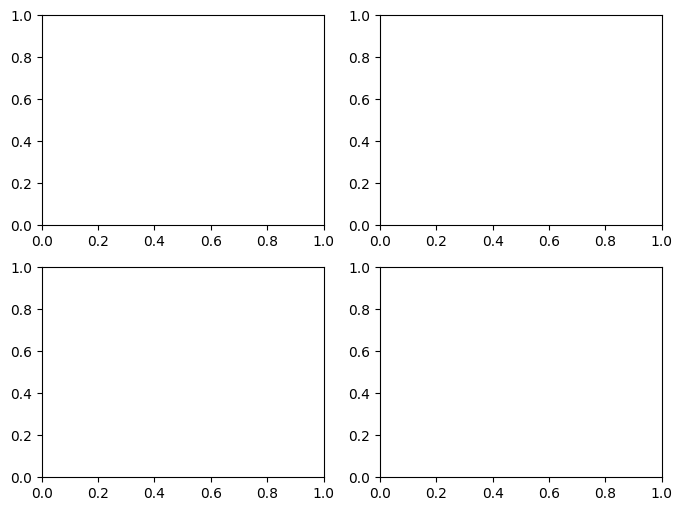

In [6]:
data = path_sig_df[ps_cols].to_numpy()
Z = linkage(data, method='ward')
# 

root_node, node_list = to_tree(Z, rd=True)


heights = Z[:, 2]
median_height = np.median(heights)

recent_ancestors = []



num_leaves = len(data)
for idx, row in enumerate(Z):
    node_id = idx + num_leaves
    tree_node = node_list[node_id]
    
    
    leaves = tree_node.pre_order()
    
    
    if row[3] == 4:
        recent_ancestors.append((row[2], leaves))
    


sample_recent_leaves = sorted(recent_ancestors, key=lambda x: x[0])


for _,leaf_group in sample_recent_leaves:
    fig, axes = plt.subplots(2,2,figsize=(8,6))#, subplot_kw={"projection":"3d"})
    for i, leaf in leaf_group:
        row = path_sig_df.iloc[leaf]
        
        traj = df[df["embryo_id"] == row["embryo_id"]][pca_cols[:2]].to_numpy()
        axes[i//2][i & 1].scatter(traj[:,0], traj[:,1], c=np.linspace(0,1,traj.shape[0]))#, visual_ps[:,2]
    plt.show()
    plt.close(fig)
    plt.close()


In [ ]:
%matplotlib inline
GRADES = ["A","B", "C","NA"]
path_sig_df["grade_indices"]  = [GRADES.index(p) for p in path_sig_df['grade'].to_list()]
PS_PCA_SIZE = 2

normed_path_sigs = StandardScaler().fit_transform(path_sig_df[ps_cols].to_numpy())
visual_ps = PCA(n_components=2).fit_transform(normed_path_sigs)
visual_ps_grade_indices = path_sig_df["grade_indices"].to_list()
visual_ps_grades = [GRADES[g] for g in visual_ps_grade_indices]
visual_ps_colors = [GRADE_COLORS[g] for g in visual_ps_grades]
fig, ax = plt.subplots(figsize=(8,6))#, subplot_kw={"projection":"3d"})
ax.scatter(visual_ps[:,0], visual_ps[:,1], c=visual_ps_colors)#, visual_ps[:,2]
plt.show()
plt.close(fig)
plt.close()


normed_path_sigs = StandardScaler().fit_transform(path_sig_df[ps_cols].to_numpy())
visual_ps = UMAP(n_components=2).fit_transform(normed_path_sigs)
visual_ps_grade_indices = path_sig_df["grade_indices"].to_list()
visual_ps_grades = [GRADES[g] for g in visual_ps_grade_indices]
visual_ps_colors = [GRADE_COLORS[g] for g in visual_ps_grades]
fig, ax = plt.subplots(figsize=(8,6))#, subplot_kw={"projection":"3d"})
ax.scatter(visual_ps[:,0], visual_ps[:,1], c=visual_ps_colors)#, visual_ps[:,2]
plt.show()
plt.close(fig)
plt.close()

normed_path_sigs = StandardScaler().fit_transform(path_sig_df[ps_cols].to_numpy())
visual_ps = phate.PHATE(knn=5, decay=15, n_jobs=-2, verbose=True).fit_transform(normed_path_sigs)
visual_ps_grade_indices = path_sig_df["grade_indices"].to_list()
visual_ps_grades = [GRADES[g] for g in visual_ps_grade_indices]
visual_ps_colors = [GRADE_COLORS[g] for g in visual_ps_grades]
fig, ax = plt.subplots(figsize=(8,6))#, subplot_kw={"projection":"3d"})
ax.scatter(visual_ps[:,0], visual_ps[:,1], c=visual_ps_colors)#, visual_ps[:,2]
plt.show()
plt.close(fig)
plt.close()


In [ ]:
def phase_ri(phase_df1, phase_df2, normalize=True):
    phase_df1 = phase_df1[phase_df1["stage"].isin(stripped_phases)] 
    phase_df2 = phase_df2[phase_df2["stage"].isin(stripped_phases)] 
    # normalize so that both have tPB2 start at 0 
    if(normalize):
        phase_df1.loc[:,["stage_begin", "stage_end"]] -= phase_df1.iloc[0]["stage_begin"]# first row is tPB2
        phase_df2.loc[:,["stage_begin", "stage_end"]] -= phase_df2.iloc[0]["stage_begin"]# first row is tPB2

    # turn into columns of index values
    new_column1 = []
    for index, row in phase_df1.iterrows():
        new_column1 += [StageDataset.PHASES.index(row["stage"])] * (row["stage_end"] - row["stage_begin"]+1)
        
    new_column2 = []
    for index, row in phase_df2.iterrows():
        new_column2 += [StageDataset.PHASES.index(row["stage"])] * (row["stage_end"] - row["stage_begin"]+1)
    
    new_column1 += [StageDataset.PHASES.index("post_phase")] * (max(len(new_column1),len(new_column2)) - len(new_column1))
    new_column2 += [StageDataset.PHASES.index("post_phase")] * (max(len(new_column1),len(new_column2)) - len(new_column2))
    assert len(new_column1) == len(new_column2), "new col lens are not the same"
    new_column1 = np.array(new_column1)
    new_column2 = np.array(new_column2)
    r_score = rand_score(new_column1, new_column2)
    # Normalize for whatever reason
    total = np.concatenate([new_column1, new_column2], axis=0)
    std_dev = total.std()
    mean = total.mean()
    new_column1 = (new_column1 - mean) / (std_dev + 1e-6)
    new_column2 = (new_column2 - mean) / (std_dev + 1e-6)
    alignment = dtw(new_column1, new_column2)
    return r_score, alignment
   
    

In [ ]:
num_nbrs = 100
nbrs = NearestNeighbors(n_neighbors=num_nbrs, algorithm='ball_tree').fit(path_sig_df[ps_cols].to_numpy())
distances, indices = nbrs.kneighbors(path_sig_df[ps_cols].to_numpy())

print(indices)


limit = 1000

dists = []
r_scores = [RunningStats() for _ in range(num_nbrs)]
dtw_scores = [RunningStats() for _ in range(num_nbrs)]
for i1 in tqdm(range(path_sig_df[ps_cols].to_numpy().shape[0])):
    for nbr_idx, i2 in enumerate(indices[i1]):
        row1 = path_sig_df.iloc[i1]
        row2 = path_sig_df.iloc[i2]
        #print(row1["embryo_id"], f" {row1['grade']}", row2["embryo_id"], f" {row2['grade']}")
        traj1 = df[df["embryo_id"] == row1["embryo_id"]][pca_cols[:2]].to_numpy()
        traj2 = df[df["embryo_id"] == row2["embryo_id"]][pca_cols[:2]].to_numpy()
        _,_,traj2 = align_trajectories_tslearn(traj1, traj2)
        fig, axes = plt.subplots(2,figsize=(8,6))#, subplot_kw={"projection":"3d"})
        axes[0].scatter(traj1[:,0], traj1[:,1], c=np.stack([np.ones(traj1.shape[0]), np.zeros(traj1.shape[0]), np.linspace(0,1,traj1.shape[0]) ], axis=1))
        axes[1].scatter(traj2[:,0], traj2[:,1], c=np.stack([np.zeros(traj2.shape[0]), np.zeros(traj2.shape[0]),  np.linspace(0,1, traj2.shape[0])], axis=1))
        fig.suptitle(f"{row1["embryo_id"]} vs {nbr_idx}-NN")
        plt.show()
        plt.close(fig)
        plt.close()

        fig, ax = plt.subplots(figsize=(8,6))#, subplot_kw={"projection":"3d"})
        ax.scatter(traj1[:,0], traj1[:,1], c=np.stack([np.ones(traj1.shape[0]), np.zeros(traj1.shape[0]), np.linspace(0,1,traj1.shape[0]) ], axis=1))
        ax.scatter(traj2[:,0], traj2[:,1], c=np.stack([np.zeros(traj2.shape[0]), np.zeros(traj2.shape[0]),  np.linspace(0,1, traj2.shape[0])], axis=1))
        fig.suptitle(f"{row1["embryo_id"]} vs {nbr_idx}-NN")
        plt.show()
        plt.close(fig)
        plt.close()
        phase_df1 = pd.read_csv(os.path.join("embryo_dataset_annotations",f"{row1["embryo_id"]}_phases.csv"), header=0) 
        phase_df1.columns = ["stage", "stage_begin","stage_end"]
        #print(phase_df1[phase_df1["stage"].isin(stripped_phases)])
        
        phase_df2 = pd.read_csv(os.path.join("embryo_dataset_annotations",f"{row2["embryo_id"]}_phases.csv"), header=0)
        phase_df2.columns = ["stage", "stage_begin","stage_end"]
        #print(phase_df2[phase_df2["stage"].isin(stripped_phases)])
        
        score, alignment = phase_ri(phase_df1, phase_df2)
        
        #print(f"rand score: {score}")
        #print(f"dtw score: {alignment}")
        
        r_scores[nbr_idx].push(score)
        dtw_scores[nbr_idx].push(alignment)
        #print("-"*50,"\n")
r_scores = np.array([[stat.mean, stat.std_dev] for stat in r_scores])
dtw_scores = np.array([[stat.mean, stat.std_dev] for stat in dtw_scores])
scores_df = pd.DataFrame(np.concatenate([r_scores, dtw_scores],axis=1), columns = ["rand", "rand_std_dev","dtw", "dtw_std_dev"])



In [ ]:
%matplotlib inline
print(scores_df)
fig, ax = plt.subplots()
labels = [f"{i}-NN" for i in range(num_nbrs)][::10]
scores = scores_df["rand"].to_numpy()[np.arange(num_nbrs) % 10 == 0]
errs = scores_df["rand_std_dev"].to_numpy()[np.arange(num_nbrs) % 10 == 0]
ax.bar(labels, scores, yerr=errs)
ax.set_ylabel('Avg. ARI')
plt.show()
print(scores_df)
fig, ax = plt.subplots()
labels = [f"{i}-NN" for i in range(num_nbrs)][::10]
scores = scores_df["dtw"].to_numpy()[np.arange(num_nbrs) % 10 == 0]
errs = scores_df["dtw_std_dev"].to_numpy()[np.arange(num_nbrs) % 10 == 0]
ax.bar(labels, scores, yerr=errs)
ax.set_ylabel('Avg. DTW')
plt.show()

In [ ]:
embryos = metadata_df["embryo_id"].unique()
stats = RunningStats()
for _ in range(100):
    np.random.shuffle(embryos)
    embryo1, embryo2 = embryos[:2]
    phase_df1 = pd.read_csv(os.path.join("embryo_dataset_annotations", f"{embryo1}_phases.csv"), header=0) 
    phase_df1.columns = ["stage", "stage_begin","stage_end"]
    print(phase_df1[phase_df1["stage"].isin(stripped_phases)])
    
    phase_df2 = pd.read_csv(os.path.join("embryo_dataset_annotations", f"{embryo2}_phases.csv"), header=0)
    phase_df2.columns = ["stage", "stage_begin","stage_end"]
    print(phase_df2[phase_df2["stage"].isin(stripped_phases)])
    score, alignment = phase_ri(phase_df1, phase_df2)
    print(f"rand score: {score}")
    stats.push(score)
    print(f"dtw score: {alignment}")
print(stats.mean, ", ", stats.std_dev)